# **Gamma Radiation Attenuation Experiment**

This notebook documents the **Gamma Radiation Attenuation Experiment**, which investigates how gamma radiation is absorbed by different materials and how the attenuation coefficient varies with energy.

### **Objectives:**
- Measure the gamma radiation spectra for different radioactive sources.
- Determine the photopeak energy and detector resolution.
- Study the attenuation of gamma radiation in aluminum layers.
- Analyze the relationship between attenuation coefficient and gamma energy.

## **Theoretical Background**
Gamma radiation consists of high-energy photons, typically in the **MeV** range, which interact with matter via three primary mechanisms:

1. **Photoelectric Effect:** The photon transfers all its energy to an electron, ejecting it from the atom. This effect is dominant for low-energy gamma radiation (<300 keV).

2. **Compton Scattering:** The photon collides with an electron, transferring part of its energy and scattering. This dominates at intermediate energies (200 keV – 2 MeV).

3. **Pair Production:** If a photon has energy >1.022 MeV, it can create an electron-positron pair. This process becomes significant at high gamma energies (>1 MeV).

### **Attenuation Law**
When gamma radiation passes through a material, its intensity decreases according to the exponential law:

$$ I = I_0 e^{-\mu x} $$

where:
- \( I \) is the transmitted intensity after passing through a material of thickness \( x \)
- \( $I_0$ \) is the initial intensity
- \( $\mu$ \) is the **linear attenuation coefficient** (cm $^{(-1)}$)
- \( x \) is the thickness of the attenuating material (cm)

The attenuation coefficient \( $\mu$ \) depends on the material and the energy of the gamma photons.

## **Experimental Setup**

![Gamma Radiation Attenuation Setup](imgs/image1.png)

The experimental apparatus includes:
- A **gamma-ray source**.
- A **scintillation detector** coupled to a photomultiplier tube.
- A **multichannel analyzer (MCA)** for spectrum recording.
- An **aluminum absorber set** to measure attenuation.

The gamma-ray source emits photons, which pass through different thicknesses of aluminum before reaching the detector. The transmitted intensity is recorded for each thickness, allowing us to determine the attenuation coefficient.

## **Data Analysis & Calculations**
1. **Extract Photopeak Energies**:
   - Identify the photopeak channel numbers \( $N_{min}$ \) and \( $N_{max}$ \).
   - Convert channel numbers to energy (keV).

2. **Gamma Radiation Attenuation**:
   - Measure intensity \( I \) for different aluminum thicknesses.
   - Fit the data to the attenuation law:

$$ I = I_0 e^{-\mu x} $$

   - Extract \( $\mu$ \) using nonlinear fitting.

3. **Plot \( $\mu$ \) vs Energy**:
   - Compare attenuation coefficients for different gamma sources.
   - Verify energy dependence of gamma attenuation.



--- Gamma Radiation Attenuation Coefficients ---
Lead Attenuation Coefficient (µ): 0.99260 cm⁻¹
Copper Attenuation Coefficient (µ): 0.47631 cm⁻¹


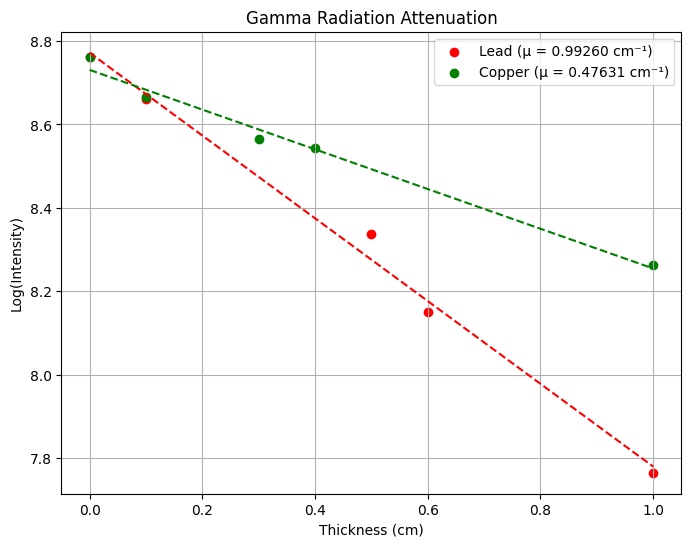

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def load_data(filename):
    """
    Load attenuation data from a CSV file.

    Parameters:
        filename (str): Path to the CSV file.

    Returns:
        tuple: Arrays of thickness (cm) and corresponding counts.
    """
    data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    thickness = data[:, 0]  # Thickness of material (cm)
    counts = data[:, 1]  # Measured radiation intensity (impulses)
    return thickness, counts

def fit_attenuation(thickness, counts):
    """
    Perform linear regression on log-transformed attenuation data.

    Parameters:
        thickness (array): Thickness of material (cm).
        counts (array): Measured radiation intensity.

    Returns:
        tuple: Fitted linear model and computed attenuation coefficient (µ).
    """
    log_counts = np.log(counts)  # Apply logarithm to transform exponential decay into a linear form
    model = LinearRegression().fit(thickness.reshape(-1, 1), log_counts)
    attenuation_coefficient = -model.coef_[0]  # µ = -slope
    return model, attenuation_coefficient

def plot_results(thickness_plumb, log_counts_plumb, model_plumb, attenuation_plumb,
                 thickness_copper, log_counts_copper, model_copper, attenuation_copper):
    """
    Plot the measured data and the fitted linear models.

    Parameters:
        thickness_plumb, thickness_copper (array): Thickness of lead and copper layers.
        log_counts_plumb, log_counts_copper (array): Log-transformed intensity values.
        model_plumb, model_copper (LinearRegression): Fitted models.
        attenuation_plumb, attenuation_copper (float): Computed attenuation coefficients.
    """
    plt.figure(figsize=(8, 6))
    plt.title('Gamma Radiation Attenuation')
    plt.xlabel('Thickness (cm)')
    plt.ylabel('Log(Intensity)')
    
    # Scatter plot for experimental data
    plt.scatter(thickness_plumb, log_counts_plumb, label=f'Lead (µ = {attenuation_plumb:.5f} cm⁻¹)', color='red')
    plt.scatter(thickness_copper, log_counts_copper, label=f'Copper (µ = {attenuation_copper:.5f} cm⁻¹)', color='green')

    # Plot fitted regression lines
    plt.plot(thickness_plumb, model_plumb.predict(thickness_plumb.reshape(-1, 1)), color='red', linestyle="dashed")
    plt.plot(thickness_copper, model_copper.predict(thickness_copper.reshape(-1, 1)), color='green', linestyle="dashed")

    plt.legend()
    plt.grid()
    plt.show()

def main():
    """Main function to process and analyze gamma radiation attenuation data."""

    # Load data for Lead and Copper
    thickness_lead, counts_lead = load_data('data/plumb.csv')
    thickness_copper, counts_copper = load_data('data/cupru.csv')

    # Fit models and compute attenuation coefficients
    model_lead, attenuation_lead = fit_attenuation(thickness_lead, counts_lead)
    model_copper, attenuation_copper = fit_attenuation(thickness_copper, counts_copper)

    # Print results
    print("\n--- Gamma Radiation Attenuation Coefficients ---")
    print(f"Lead Attenuation Coefficient (µ): {attenuation_lead:.5f} cm⁻¹")
    print(f"Copper Attenuation Coefficient (µ): {attenuation_copper:.5f} cm⁻¹")

    # Plot results
    plot_results(thickness_lead, np.log(counts_lead), model_lead, attenuation_lead,
                 thickness_copper, np.log(counts_copper), model_copper, attenuation_copper)

if __name__ == '__main__':
    main()
